In [1]:
#Import Libs
from matplotlib import pyplot as plot
import matplotlib as mpl
import urllib.request
import urllib.parse
import numpy as np
import math
import cv2

In [4]:
#URL Image
image_url = 'https://raw.githubusercontent.com/jrafa1607/Computational-Vision-In-Python/main/-%20Images/objects.bmp'

In [5]:
#Open the Image
with urllib.request.urlopen(image_url) as url:
    s = url.read()

In [6]:
#Convert to a Numpy Array and Decode with cv2
img = cv2.imdecode(np.frombuffer(s, np.uint8), -1)

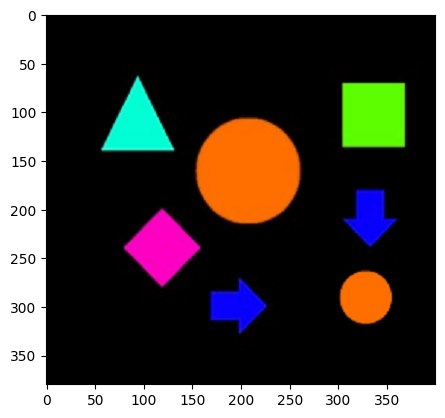

In [7]:
#Show the Image
plot.imshow(img,cmap='gray')
plot.show()

In [8]:
#Convert to Grayscale
img_gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [9]:
#Define the Threshold
T = 50

In [10]:
#Apply the Threshold
T ,img_bin = cv2.threshold(img_gray, T, 255, cv2.THRESH_BINARY)

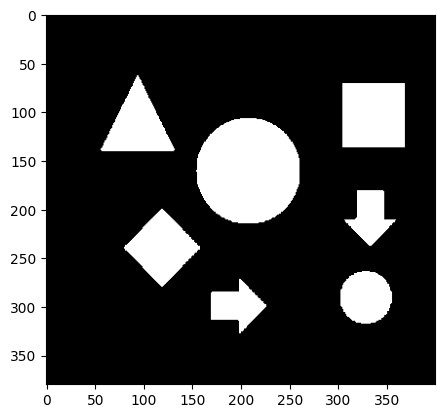

In [11]:
#Show the Results
plot.imshow(img_bin,cmap='gray')
plot.show()

### **Connected Components**

Connected Components are sets of connected pixels in a binary image. In image processing, identifying connected components is crucial for various tasks like object detection, segmentation, and analysis.

OpenCV's `cv2.connectedComponentsWithStats()` function is used to find these components. It labels each connected region with a unique ID and provides statistics about each component, such as its area, bounding box, and centroid.

The `connectivity` parameter (e.g., `connectivity=4` or `connectivity=8`) specifies how pixels are considered 'connected'.
*   **4-connectivity**: Pixels are connected if they share a common edge (up, down, left, right).
*   **8-connectivity**: Pixels are connected if they share a common edge or a common corner (includes diagonals).

Here's a breakdown of the function's output:

*   **`numCCs`**: The total number of connected components found, including the background.
*   **`imgLabels`**: A labeled image where each pixel is assigned the label of its connected component. The background is typically labeled 0.
*   **`stats`**: A NumPy array containing statistics for each label. Each row corresponds to a component, and columns represent properties like:
    *   `cv2.CC_STAT_LEFT`: The leftmost x-coordinate of the bounding box.
    *   `cv2.CC_STAT_TOP`: The topmost y-coordinate of the bounding box.
    *   `cv2.CC_STAT_WIDTH`: The width of the bounding box.
    *   `cv2.CC_STAT_HEIGHT`: The height of the bounding box.
    *   `cv2.CC_STAT_AREA`: The total area (number of pixels) of the component.
*   **`centroids`**: A NumPy array containing the centroids (center of mass) for each connected component.

In [12]:
#Show the Components
(numCCs, imgLabels, stats, centroids) = cv2.connectedComponentsWithStats(img_bin, connectivity=4)
print("Total: " + str(numCCs-1))

Total: 7


In [13]:
#Show the Statics
print(stats)

[[     0      0    400    380 126783]
 [    56     63     76     78   3064]
 [   304     71     64     66   4224]
 [   154    107    106    108   9149]
 [   306    181     53     57   1615]
 [    80    200     78     80   3217]
 [   302    264     53     54   2275]
 [   169    272     57     56   1673]]


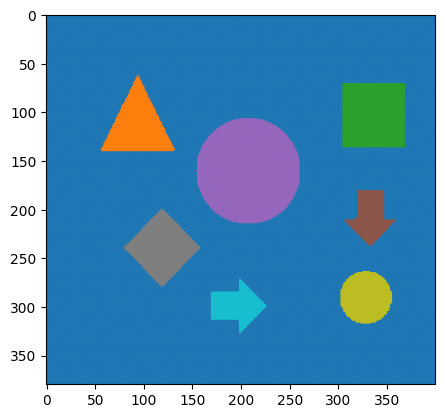

In [14]:
#Show the Image with Objects [ Each One with a Specific Color ]
plot.imshow(imgLabels, cmap='tab10');

In [15]:
#Show some Results
print("cv2.CC_STAT_LEFT:" + str(stats[1, [cv2.CC_STAT_LEFT]]))
print("cv2.CC_STAT_TOP:" + str(stats[1, [cv2.CC_STAT_TOP]]))
print("cv2.CC_STAT_WIDTH:" + str(stats[1, [cv2.CC_STAT_WIDTH]]))
print("cv2.CC_STAT_HEIGHT:" + str(stats[1, [cv2.CC_STAT_HEIGHT]]))
print("cv2.CC_STAT_AREA:" + str(stats[1, [cv2.CC_STAT_AREA]]))

cv2.CC_STAT_LEFT:[56]
cv2.CC_STAT_TOP:[63]
cv2.CC_STAT_WIDTH:[76]
cv2.CC_STAT_HEIGHT:[78]
cv2.CC_STAT_AREA:[3064]
